# Deep Semantic Search — Full Demo

This notebook demonstrates all the functionality of the `deep-semantic-search` library:

1. **Image Search** — Search images by text or by image similarity
2. **Text Search** — Semantic text search over documents
3. **Image Clustering** — Cluster images using KMeans on CLIP embeddings
4. **Image Captioning** — Generate captions for images using BLIP
5. **RAG (Question Answering)** — Ask questions over text documents

## Setup

Make sure the package is installed:
```bash
pip install deep-semantic-search
# or from source:
pip install -e ..
```

In [3]:
import os
from pathlib import Path

# Paths to demo data
DEMO_DIR = Path(".").resolve()
IMAGE_DIR = DEMO_DIR / "data" / "images"
TEXT_DIR = DEMO_DIR / "data" / "texts"

print(f"Demo directory: {DEMO_DIR}")
print(f"Image directory: {IMAGE_DIR} ({len(list(IMAGE_DIR.iterdir()))} files)")
print(f"Text directory: {TEXT_DIR} ({len(list(TEXT_DIR.iterdir()))} files)")

Demo directory: F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo
Image directory: F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\images (15 files)
Text directory: F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\texts (5 files)


## 1. Image Search

Load images, build a CLIP index, and search by text or by image.

In [4]:
from deep_semantic_search import LoadImageData, ImageIndexer, ImageSearcher

# Load all images from the demo folder
loader = LoadImageData()
image_paths = loader.from_folder([str(IMAGE_DIR)])
print(f"Loaded {len(image_paths)} images")
for p in image_paths:
    print(f"  {os.path.basename(p)}")

Loaded 15 images
  abstract_blue.jpg
  abstract_green.jpg
  abstract_red.jpg
  animal_bird.jpg
  animal_cat.jpg
  animal_dog.jpg
  city_skyline.jpg
  city_street.jpg
  food_fruit.jpg
  food_pasta.jpg
  landscape_desert.jpg
  landscape_forest.jpg
  landscape_mountain.jpg
  landscape_ocean.jpg
  landscape_sunset.jpg


In [5]:
# Build the CLIP index (auto-skips if already built)
indexer = ImageIndexer(
    image_paths,
    metadata_dir=DEMO_DIR / "metadata" / "clip_index"
)
indexer.run_index(reindex=True)
print(f"Indexed {len(indexer.image_data)} images")

f:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 56861.26it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting features: 100%|██████████| 15/15 [00:00<00:00, 29.54it/s]

Indexed 15 images


In [6]:
# Search by text query
searcher = ImageSearcher(indexer)
results = searcher.search_by_text("a blue sky with water", n=5)

print("\nSearch results for 'a blue sky with water':")
for path, score in results.items():
    print(f"  {score:.4f}  {os.path.basename(path)}")


Search results for 'a blue sky with water':
  2.4225  landscape_ocean.jpg
  2.4070  animal_bird.jpg
  2.1119  city_skyline.jpg
  2.0652  abstract_blue.jpg
  1.9623  city_street.jpg


In [7]:
# Search by text — different query
results = searcher.search_by_text("warm red colors, sunset", n=5)

print("\nSearch results for 'warm red colors, sunset':")
for path, score in results.items():
    print(f"  {score:.4f}  {os.path.basename(path)}")


Search results for 'warm red colors, sunset':
  2.1599  landscape_sunset.jpg
  1.9896  food_fruit.jpg
  1.7298  landscape_desert.jpg
  1.7162  abstract_red.jpg
  1.6572  food_pasta.jpg


In [8]:
# Search by image — find images similar to the first one
query_image = image_paths[0]
results = searcher.search_by_image(query_image, n=5)

print(f"\nImages similar to '{os.path.basename(query_image)}':")
for path, score in results.items():
    print(f"  {score:.4f}  {os.path.basename(path)}")


Images similar to 'abstract_blue.jpg':
  0.0000  abstract_blue.jpg
  0.1177  abstract_red.jpg
  0.1638  abstract_green.jpg
  0.4942  animal_bird.jpg
  0.4978  landscape_ocean.jpg


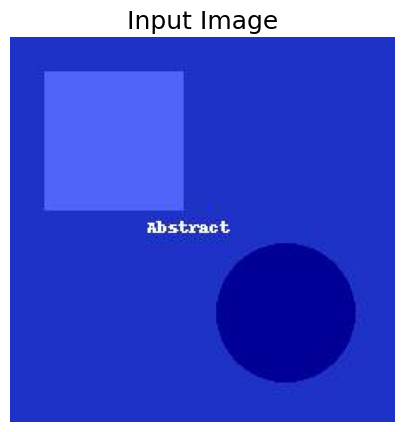

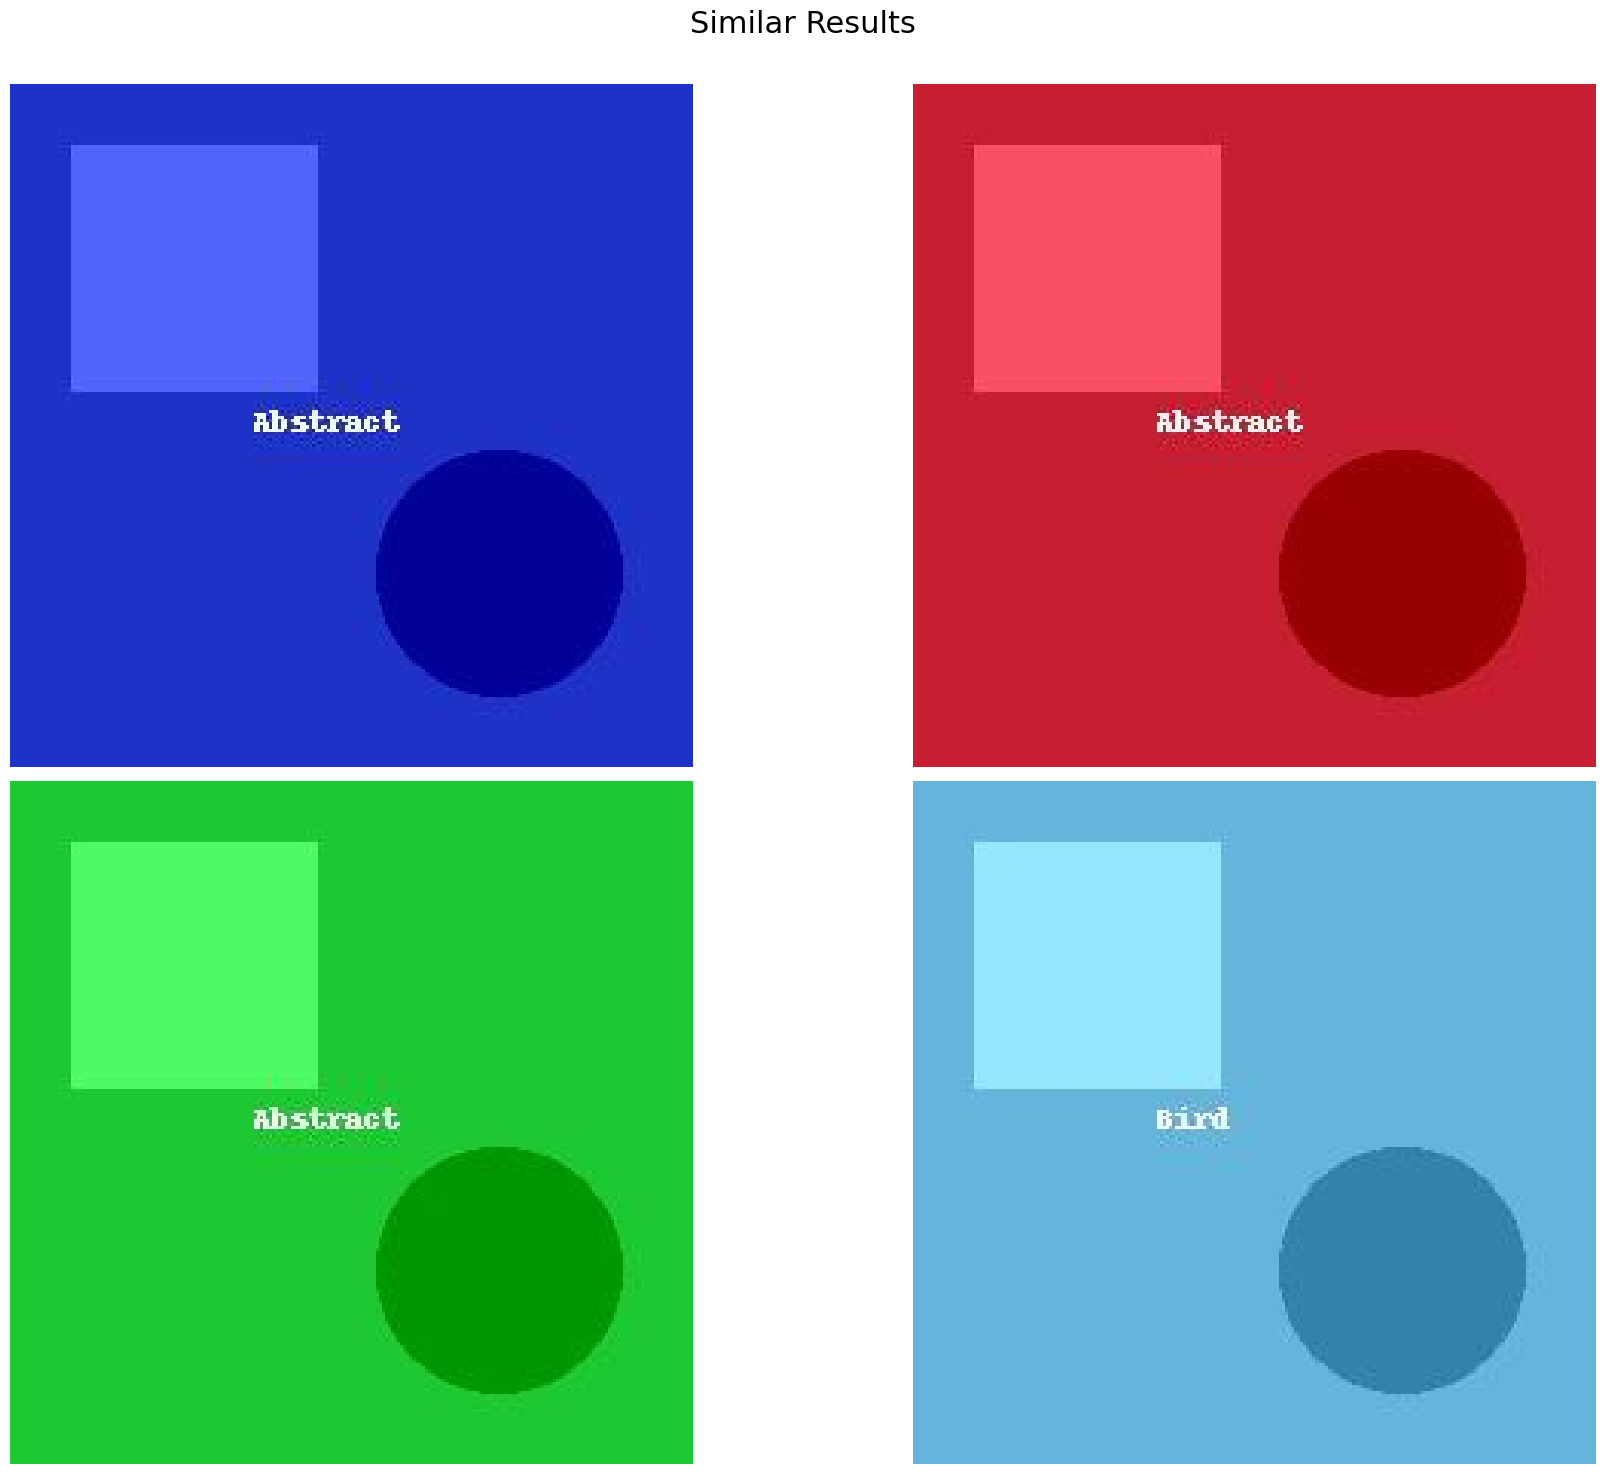

In [9]:
# Visualize similar images (opens matplotlib plots)
searcher.plot_similar_images(query_image, n=4)

## 2. Text Search

Load text documents, create embeddings, and search by semantic similarity.

In [10]:
from deep_semantic_search import LoadTextData, TextEmbedder, TextSearch

# Load text files
text_loader = LoadTextData()
corpus = text_loader.from_folder(str(TEXT_DIR))

print(f"Loaded {len(corpus)} documents:")
for path, text in corpus.items():
    preview = text[:80].replace('\n', ' ')
    print(f"  {os.path.basename(path)}: \"{preview}...\"")

Loaded 5 documents:
  computer_vision.txt: "Computer vision is the field of artificial intelligence that enables machines to..."
  deep_learning.txt: "Deep learning is a subset of machine learning that uses neural networks with man..."
  python_ml.txt: "Python is one of the most popular programming languages for data science and art..."
  rag_overview.txt: "Retrieval-Augmented Generation (RAG) combines the strengths of information retri..."
  semantic_search.txt: "Semantic search goes beyond traditional keyword matching by understanding the me..."


In [11]:
# Create sentence embeddings
embedder = TextEmbedder(
    metadata_dir=DEMO_DIR / "metadata" / "text_embeddings"
)
embedder.embed(corpus, reindex=True)
print("Embeddings created successfully!")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14202.74it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1/1 [00:00<00:00, 11.42it/s]

Embeddings created successfully!


In [12]:
# Search for similar documents
search = TextSearch(embedder)

queries = [
    "How does CLIP work for image understanding?",
    "What is retrieval augmented generation?",
    "Which Python libraries are popular for AI?",
    "How do neural networks learn from data?",
]

for query in queries:
    results = search.find_similar(query, top_n=3)
    print(f"\nQuery: '{query}'")
    for r in results:
        print(f"  Score: {r['score']:.4f}  File: {os.path.basename(r['path'])}")
        print(f"         \"{r['text'][:100].replace(chr(10), ' ')}...\"")


Query: 'How does CLIP work for image understanding?'
  Score: 0.6185  File: computer_vision.txt
         "Computer vision is the field of artificial intelligence that enables machines to interpret and under..."
  Score: 0.3285  File: rag_overview.txt
         "Retrieval-Augmented Generation (RAG) combines the strengths of information retrieval and text genera..."
  Score: 0.2258  File: deep_learning.txt
         "Deep learning is a subset of machine learning that uses neural networks with many layers. These deep..."

Query: 'What is retrieval augmented generation?'
  Score: 0.5647  File: rag_overview.txt
         "Retrieval-Augmented Generation (RAG) combines the strengths of information retrieval and text genera..."
  Score: 0.5585  File: computer_vision.txt
         "Computer vision is the field of artificial intelligence that enables machines to interpret and under..."
  Score: 0.3164  File: deep_learning.txt
         "Deep learning is a subset of machine learning that uses neural 

## 3. Image Clustering

Cluster images into groups using KMeans on CLIP feature vectors.

In [13]:
from deep_semantic_search import ImageClusterer

# Cluster images into 3 groups
clusterer = ImageClusterer(indexer)
cluster_df = clusterer.cluster(n_clusters=3)

print("Clustering results:")
print(cluster_df[["images_paths", "cluster", "topic"]].to_string(index=False))

running k-means on cpu..


[running kmeans]: 2it [00:00, 666.61it/s, center_shift=0.000000, iteration=2, tol=0.000100]

Clustering results:
                                                                                                      images_paths  cluster     topic
     F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\images\abstract_blue.jpg        1 cluster_1
    F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\images\abstract_green.jpg        1 cluster_1
      F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\images\abstract_red.jpg        1 cluster_1
       F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\images\animal_bird.jpg        0 cluster_0
        F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\images\animal_cat.jpg        0 cluster_0
        F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\data\images\animal_dog.jpg        0 cluster_0
      F:\Projects\Programming\IT Step\AI_2

In [14]:
# View images per cluster
for cluster_id in sorted(cluster_df["cluster"].unique()):
    images = clusterer.get_cluster_images(int(cluster_id))
    print(f"\nCluster {cluster_id} ({len(images)} images):")
    for img in images:
        print(f"  {os.path.basename(img)}")


Cluster 0 (11 images):
  animal_bird.jpg
  animal_cat.jpg
  animal_dog.jpg
  city_skyline.jpg
  city_street.jpg
  food_fruit.jpg
  landscape_desert.jpg
  landscape_forest.jpg
  landscape_mountain.jpg
  landscape_ocean.jpg
  landscape_sunset.jpg

Cluster 1 (3 images):
  abstract_blue.jpg
  abstract_green.jpg
  abstract_red.jpg

Cluster 2 (1 images):
  food_pasta.jpg


In [15]:
# Save clusters to organized folders
save_dir = DEMO_DIR / "output" / "clusters"
clusterer.save_clusters(str(save_dir))
print(f"Clusters saved to {save_dir}")

for d in sorted(save_dir.iterdir()):
    files = list(d.iterdir())
    print(f"  {d.name}/  ({len(files)} images)")

Clusters saved to F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\output\clusters
  0_cluster_0/  (11 images)
  1_cluster_1/  (3 images)
  2_cluster_2/  (1 images)


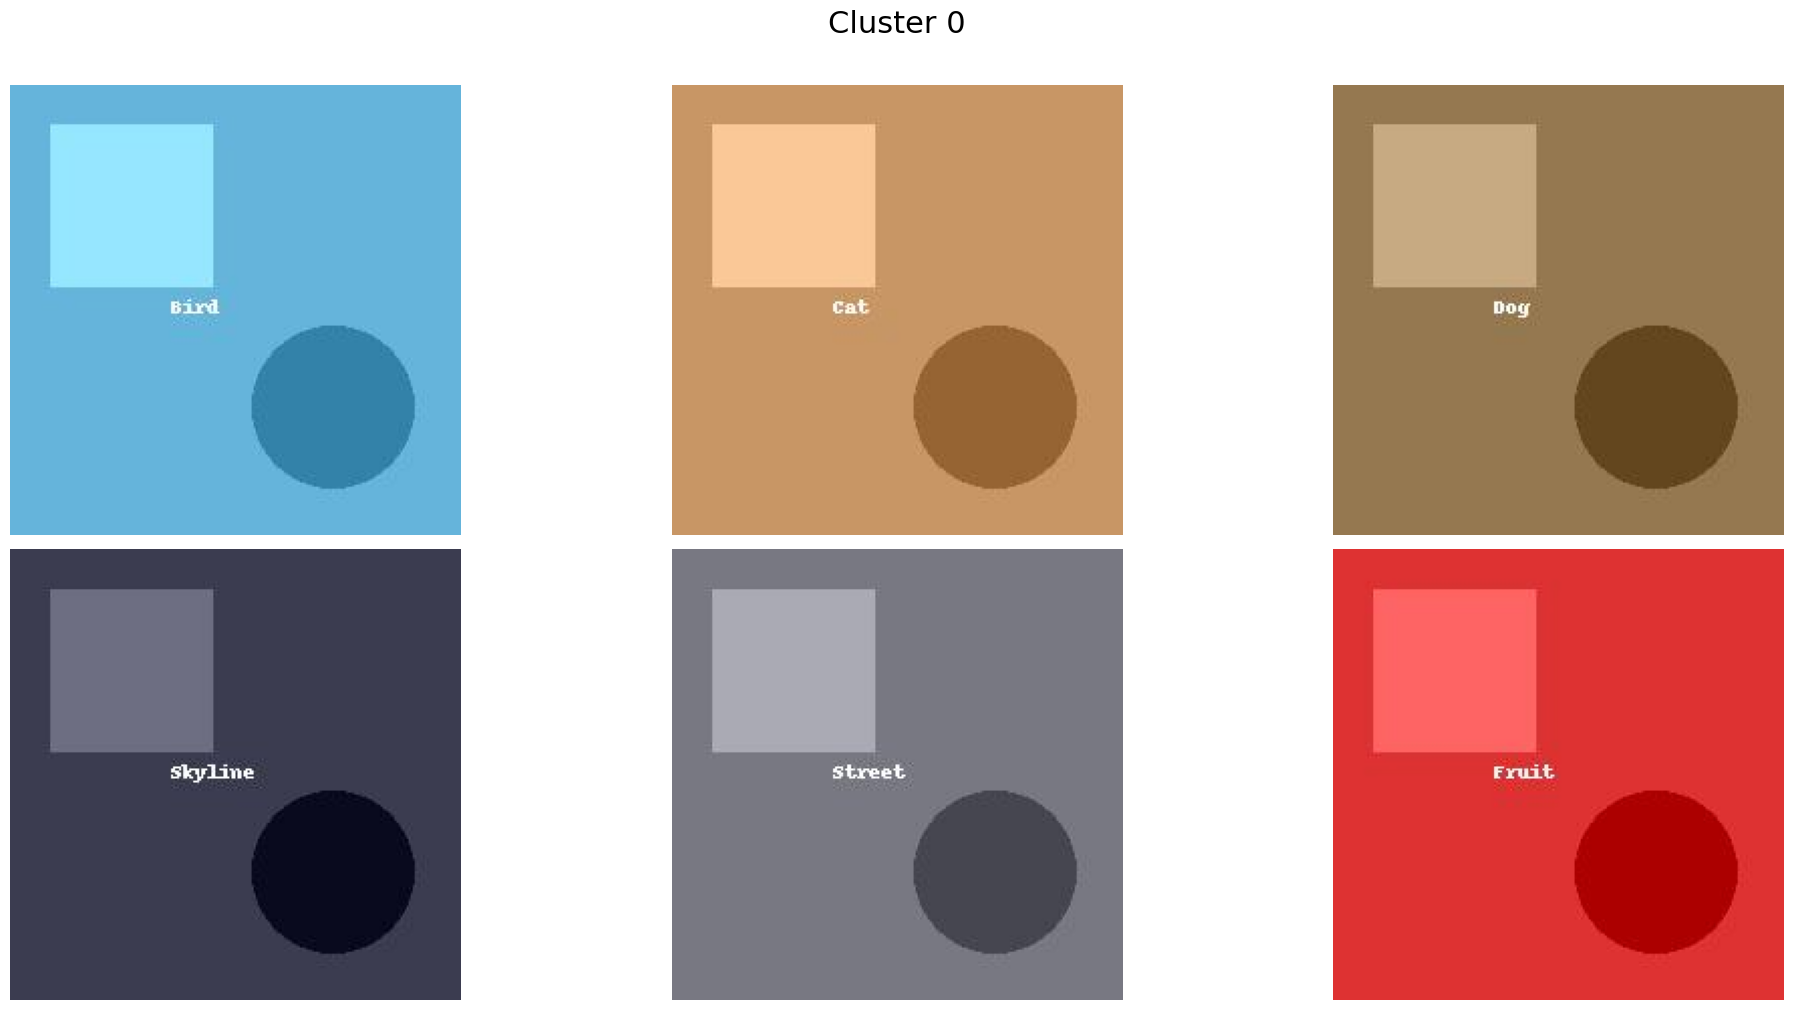

In [16]:
# Plot a cluster
clusterer.plot_cluster(0, n=6)

## 4. Image Captioning

Generate natural language captions for images using BLIP.

> **Note:** This downloads the BLIP model (~1.5 GB) on first run.

In [17]:
from deep_semantic_search import ImageCaptioner

captioner = ImageCaptioner()

# Caption a subset of images
sample_paths = image_paths[:5]
captions_df = captioner.caption(sample_paths)

print("Image Captions:")
for _, row in captions_df.iterrows():
    print(f"  {os.path.basename(row['image_path'])}: {row['caption']}")

Loading weights: 100%|██████████| 616/616 [00:00<00:00, 12789.79it/s]
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Captioning images:   0%|          | 0/5 [00:00<?, ?it/s]f:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\.venv\Lib\site-packages\transformers\generation\utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=24) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
Captioning images: 100%|██████████| 5/5 [00:05<00:00,  1.07s/it]

Image Captions:
  abstract_blue.jpg: this is a picture of a blue background with a black circle
  abstract_green.jpg: this is a green screen with a black circle and a green square
  abstract_red.jpg: this is a red book cover with a red circle and a red square
  animal_bird.jpg: this is a picture of a blue square and a blue circle
  animal_cat.jpg: this is a picture of a cat and a dog on a brown background


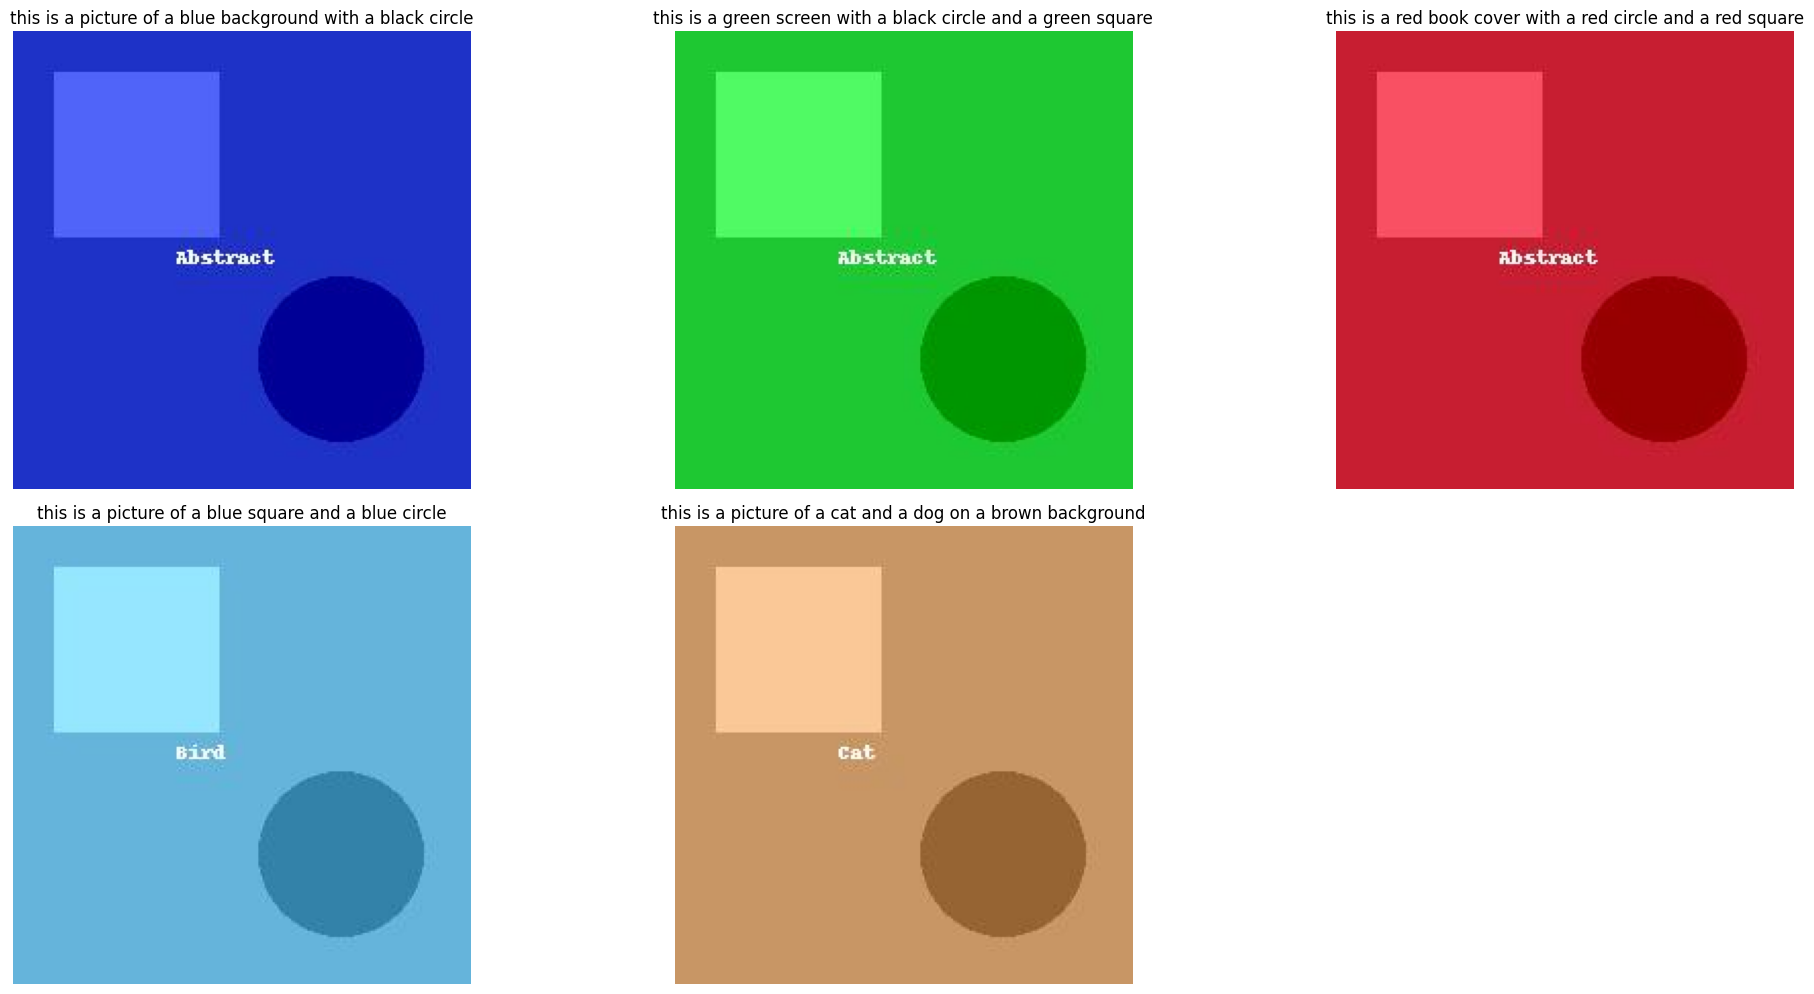

In [18]:
# Visualize captioned images
captioner.plot_captioned_images(captions_df, caption_col="caption")

## 4b. Clustering with Captioning

Combine clustering with BLIP captioning to auto-generate topic labels.

In [19]:
# Cluster with captioner for automatic topic labels
# Note: This requires Ollama running locally for LLM-based topic extraction
# If Ollama is not available, topics will default to generic labels
clusterer_with_topics = ImageClusterer(indexer)
cluster_df_captioned = clusterer_with_topics.cluster(n_clusters=3, captioner=captioner)

print("Clusters with auto-generated topics:")
for cluster_id in sorted(cluster_df_captioned["cluster"].unique()):
    cluster_data = cluster_df_captioned[cluster_df_captioned["cluster"] == cluster_id]
    topic = cluster_data["topic"].iloc[0]
    count = len(cluster_data)
    print(f"  Cluster {cluster_id} — Topic: '{topic}' ({count} images)")

running k-means on cpu..


[running kmeans]: 2it [00:00, 1000.07it/s, center_shift=0.000000, iteration=2, tol=0.000100]
Captioning images:   0%|          | 0/12 [00:00<?, ?it/s]f:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\.venv\Lib\site-packages\transformers\generation\utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=24) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
Captioning images:   0%|          | 0/1 [00:00<?, ?it/s]f:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\.venv\Lib\site-packages\transformers\generation\utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=24) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
Captioning images:   0%|          | 0/2 [00:00<?, ?it/s]f:\Projects\Programming\IT Step\AI_2023\course_project\c

Clusters with auto-generated topics:
  Cluster 0 — Topic: 'other' (12 images)
  Cluster 1 — Topic: 'other' (1 images)
  Cluster 2 — Topic: 'other' (2 images)


## 5. RAG — Question Answering

Answer questions over text documents using Retrieval-Augmented Generation.

> **Note:** Requires Ollama running locally with a model (default: `mistral:7b`).
> 
> ```bash
> # Install Ollama: https://ollama.ai
> ollama pull mistral:7b
> ```

In [20]:
from deep_semantic_search import ask_question

# Get all text content
text_data = list(corpus.values())
print(f"Using {len(text_data)} documents for RAG")

# Ask a question
question = "What is CLIP and how is it used for image search?"
print(f"\nQuestion: {question}")

try:
    answer = ask_question(text_data, question)
    print(f"\nAnswer: {answer}")
except Exception as e:
    print(f"\nRAG requires Ollama to be running. Error: {e}")

Using 5 documents for RAG

Question: What is CLIP and how is it used for image search?

RAG requires Ollama to be running. Error: RAG question answering failed: Could not import gpt4all library. Please install the gpt4all library to use this embedding model: pip install gpt4all


In [21]:
# Ask another question
question2 = "What are the steps in a RAG pipeline?"
print(f"Question: {question2}")

try:
    answer2 = ask_question(text_data, question2)
    print(f"\nAnswer: {answer2}")
except Exception as e:
    print(f"\nRAG requires Ollama to be running. Error: {e}")

Question: What are the steps in a RAG pipeline?

RAG requires Ollama to be running. Error: RAG question answering failed: Could not import gpt4all library. Please install the gpt4all library to use this embedding model: pip install gpt4all


In [22]:
# RAG with custom parameters
question3 = "What Python libraries are useful for machine learning?"
print(f"Question: {question3}")

try:
    answer3 = ask_question(
        text_data,
        question3,
        chunk_size=500,
        chunk_overlap=50,
    )
    print(f"\nAnswer: {answer3}")
except Exception as e:
    print(f"\nRAG requires Ollama to be running. Error: {e}")

Question: What Python libraries are useful for machine learning?

RAG requires Ollama to be running. Error: RAG question answering failed: Could not import gpt4all library. Please install the gpt4all library to use this embedding model: pip install gpt4all


## 6. CLI Usage

The package also includes a `dss` CLI tool. Here are equivalent shell commands:

```bash
# Image search
dss image-search --folder ./data/images --query "blue sky" --top 5

# Text search
dss text-search --folder ./data/texts "neural networks" --top 3

# Image clustering
dss image-cluster --folder ./data/images --clusters 3 --save-dir ./output/clusters

# RAG question answering
dss ask --folder ./data/texts "What is CLIP?"
```

## Cleanup

Run this cell to remove generated metadata and output files.

In [23]:
import shutil

for d in ["metadata", "output"]:
    path = DEMO_DIR / d
    if path.exists():
        shutil.rmtree(path)
        print(f"Removed {path}")

print("Cleanup complete!")

Removed F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\metadata
Removed F:\Projects\Programming\IT Step\AI_2023\course_project\chat_with_your_data\demo\output
Cleanup complete!
